# Biblioteka matplotlib
biblioteka = zbiór pakietów <br>
pakiet = zbiór modułów <br>
moduł = pojedynczy plik

In [1]:
import seaborn as sns # pakiet do wizualizacji danych bazujący na matplotlib

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [2]:
df = sns.load_dataset('diamonds')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


In [3]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
import matplotlib.pyplot as plt     # importujemy moduł pyplot biblioteki matplotlib (a nie całą bibliotekę)


## Sposób 1. Funkcja figure()

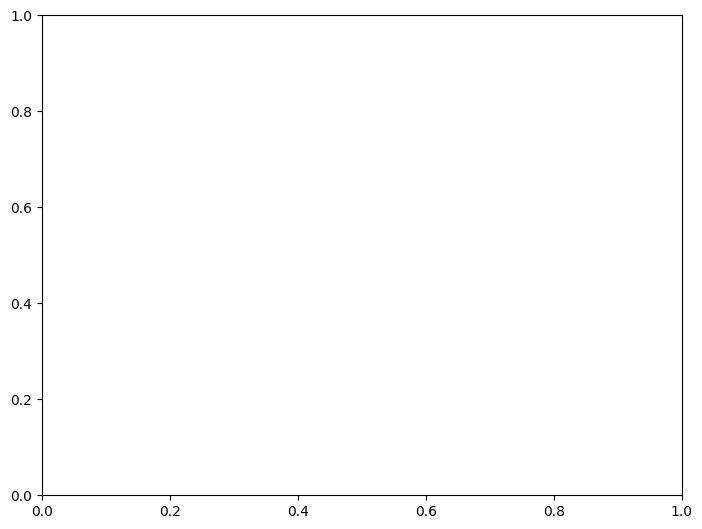

In [5]:
fig = plt.figure()    # 1 tworzymy obiekt typu Figure (kontener) - przestrzeń na której mżona umieścić wykres
ax = fig.add_axes([0, 0, 1, 1]) # 2 tworzymy osie pierwszego wykresu - pierwsza wartość pozioma (szerokść) druga pionowa (wysokość)
plt.savefig('wykres.png', dpi=300)


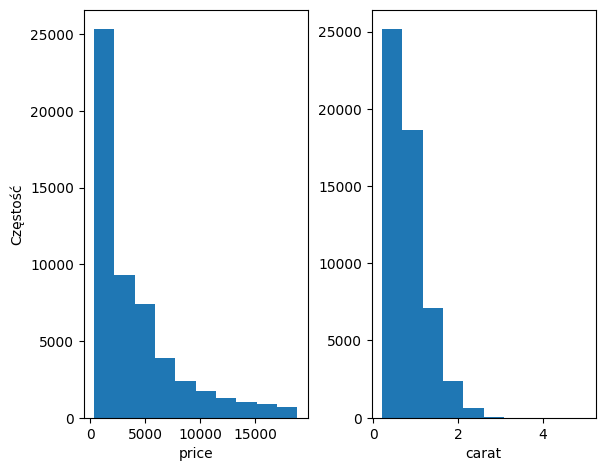

In [6]:
fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.35, 0.85]) # to też jest obiekt
ax.hist(df['price'])          # 3 określamy typ wykresu i zmienne (metody obiektu ax - hist)
ax.set_xlabel('price')
ax.set_ylabel('Częstość')
ax1 = fig.add_axes([0.6, 0.1, 0.35, 0.85])
ax1.hist(df['carat'])
ax1.set_xlabel('carat')
plt.savefig('wykres.png', dpi=300)
#print(type(df['price']))    # pandas Series


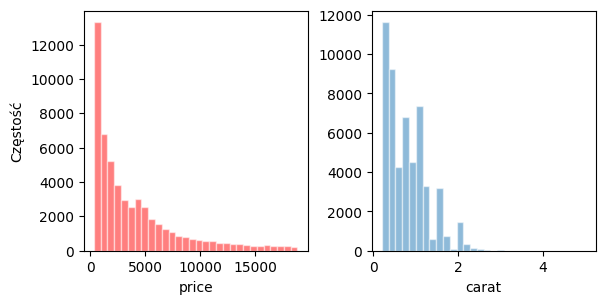

In [7]:
fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.35, 0.5])
ax.hist(df['price'], color = "red", alpha = 0.5, edgecolor = "white", linewidth = 1, bins = 30)
ax.set_xlabel('price')
ax.set_ylabel('Częstość')
ax1 = fig.add_axes([0.6, 0.1, 0.35, 0.5])
ax1.hist(df['carat'], alpha = 0.5, edgecolor = "white", linewidth = 1, bins = 30)
ax1.set_xlabel('carat')

plt.savefig('wykres.png', dpi=300)


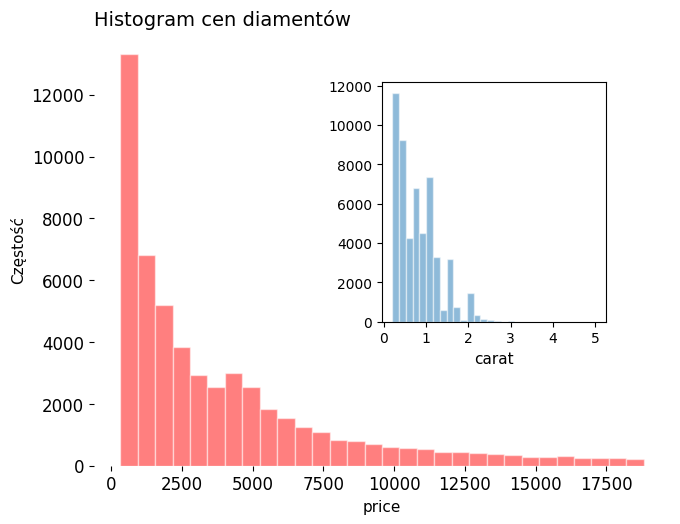

In [8]:
fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.9, 0.9])
ax.hist(df['price'], color = "red", alpha = 0.5, edgecolor = "white", linewidth = 1, bins = 30)
ax.set_xlabel('price', fontsize = 11)
ax.set_ylabel('Częstość', fontsize = 11)
ax1 = fig.add_axes([0.6, 0.4, 0.35, 0.5])
ax1.hist(df['carat'], alpha = 0.5, edgecolor = "white", linewidth = 1, bins = 30)
ax1.set_xlabel('carat', fontsize = 11)

ax1.set_xticks([0, 1, 2, 3, 4, 5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

#ax1.set_facecolor('#f0f0f0')
#fig.patch.set_facecolor('#AAAAAA')


ax.tick_params(axis='both', labelsize=12)
ax.set_title('Histogram cen diamentów', fontsize = 14, loc = "left")



plt.savefig('wykres.png', dpi=300)

## Sposób 2. Funkcja subplots()

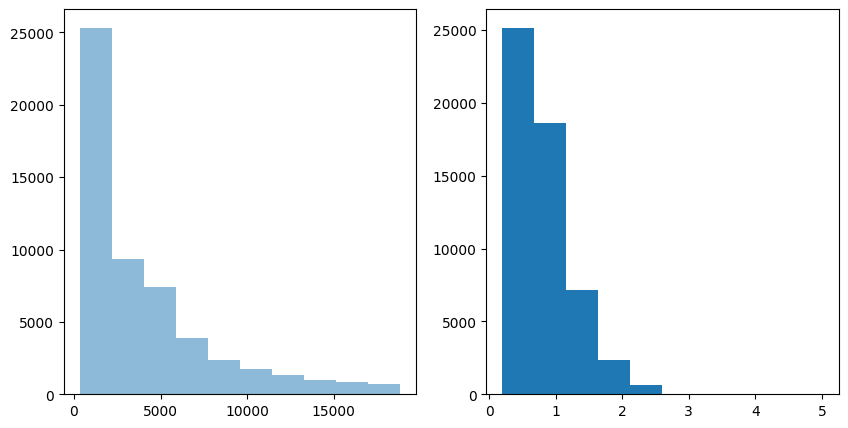

In [9]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5)) # szerokość wysokość w calach
# funkcja modułu matplotlib.pyplot "subplot" tworzy obiekt Figure i zestaw (bądź jeden) obiektów Axes
ax[0].hist(df['price'], alpha = 0.5)
ax[1].hist(df['carat'])
plt.savefig('wykres.png', dpi=300)

<class 'pandas.core.series.Series'>
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64


<BarContainer object of 5 artists>

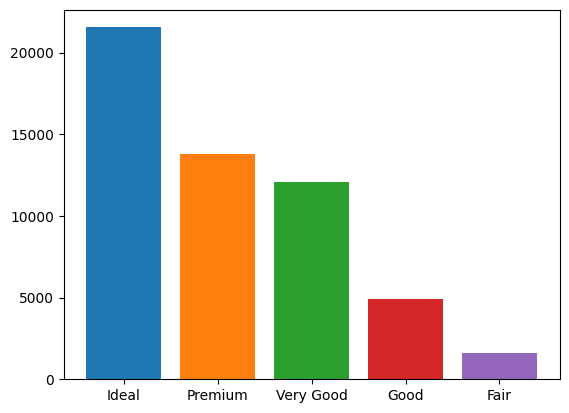

In [10]:
fig, ax = plt.subplots()  # nie określamy większej liczby wykresów
counts = df["cut"].value_counts() # value_counts() metoda obiektu Series z Pandas
print(type(counts))
print(counts)
colors = plt.get_cmap("tab10").colors
ax.bar(counts.index, counts.values, color = colors) # więc tu bez indeksu [0]

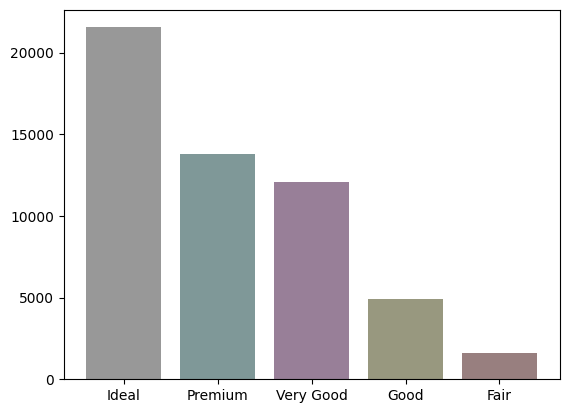

In [11]:
fig, ax = plt.subplots()
counts = df["cut"].value_counts()
colors = ["#333333","#003333","#330033","#333300","#330000"]
ax.bar(counts.index, counts.values, color = colors, alpha = .5)
plt.savefig('wykres.png', dpi=300)

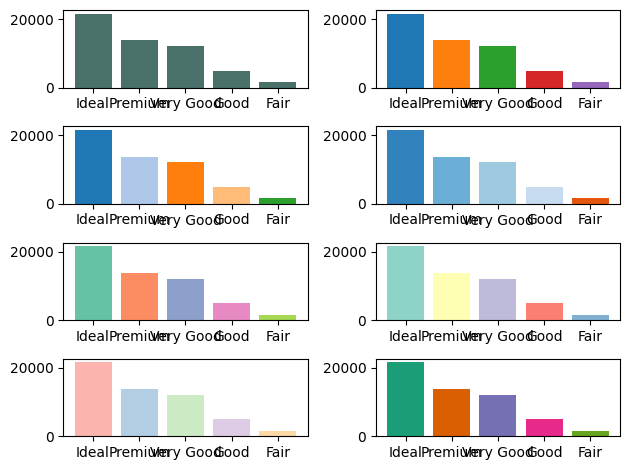

In [12]:
fig, ax = plt.subplots(nrows = 4, ncols = 2)
counts = df["cut"].value_counts()
c1 = plt.get_cmap("tab10").colors
c2 = plt.get_cmap("tab20").colors
c3 = plt.get_cmap("tab20c").colors
c4 = plt.get_cmap("Set2").colors
c5 = plt.get_cmap("Set3").colors
c6 = plt.get_cmap("Pastel1").colors
c7 = plt.get_cmap("Dark2").colors
ax[0][0].bar(counts.index, counts.values, color = "#4A7169FF")
ax[0][1].bar(counts.index, counts.values, color = c1)
ax[1][0].bar(counts.index, counts.values, color = c2)
ax[1][1].bar(counts.index, counts.values, color = c3)
ax[2][0].bar(counts.index, counts.values, color = c4)
ax[2][1].bar(counts.index, counts.values, color = c5)
ax[3][0].bar(counts.index, counts.values, color = c6)
ax[3][1].bar(counts.index, counts.values, color = c7)

plt.tight_layout()  # nie chcemy żeby się wykresy nachodziły na siebie (kolejna metoda)



## Sposób 3. Funkcie modułu matplotlib.pyplot (np. scatter)
Uproszczony sposób tworzenia wykresów

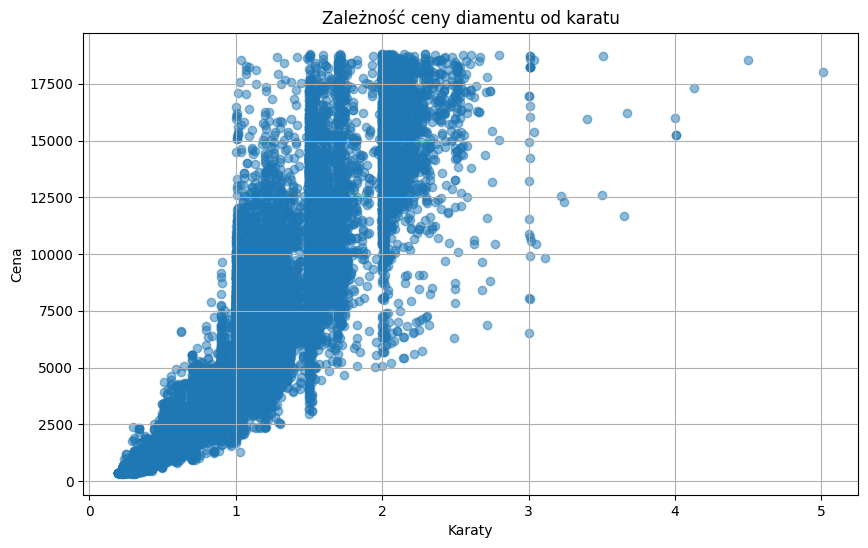

In [13]:
plt.figure(figsize=(10, 6))     # określamy wielkość wykresu w calach
plt.scatter(df['carat'], df['price'], alpha=0.5)    # typ wykresu
plt.xlabel('Karaty')
plt.ylabel('Cena')
plt.title('Zależność ceny diamentu od karatu')
plt.grid(True)
# plt.show()
plt.savefig('wykres.png', dpi=300)

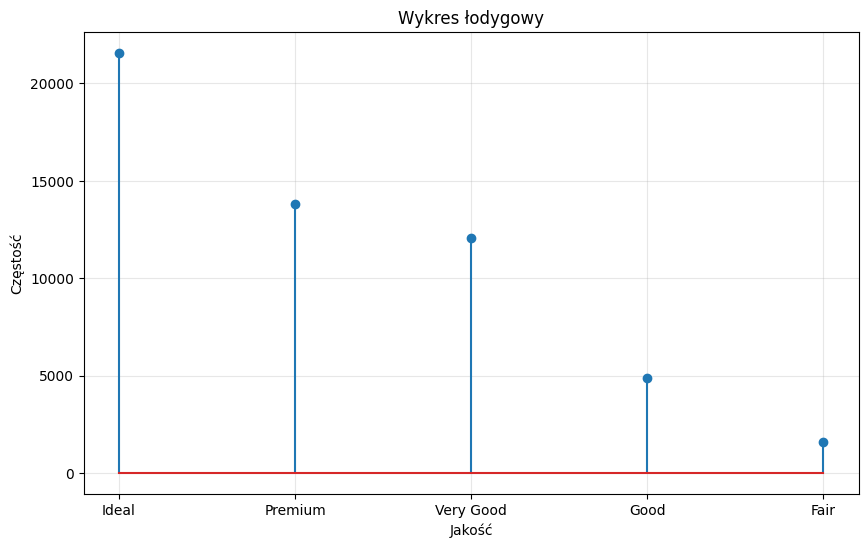

In [14]:
counts = df["cut"].value_counts()
# Wykres łodygowy
plt.figure(figsize=(10, 6))
plt.stem(counts.index, counts.values)
plt.xlabel('Jakość')
plt.ylabel('Częstość')
plt.title('Wykres łodygowy')
plt.grid(True, alpha=0.3)


([<matplotlib.patches.Wedge at 0x7da5ca6ec4d0>,
 [Text(0.3414415318010835, 1.0456661419216604, 'Ideal'),
  Text(-1.0837708009350322, -0.1882574063367466, 'Premium'),
  Text(0.11867640474968727, -1.0935794031325246, 'Very Good'),
  Text(0.9790873764255467, -0.5013859883604049, 'Good'),
  Text(1.0951675106156111, -0.1029957459898499, 'Fair')])

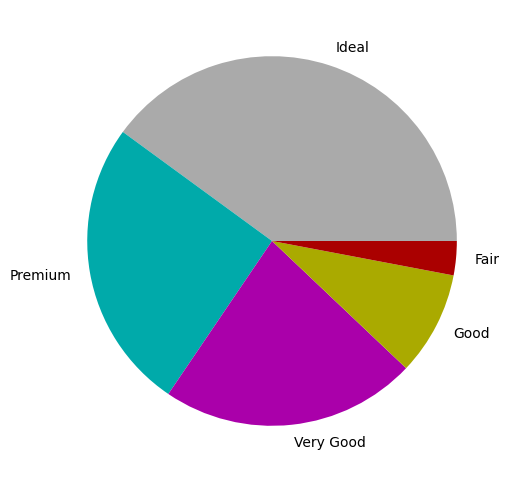

In [15]:
counts = df["cut"].value_counts()
# Wykres kołowy
plt.figure(figsize=(6, 6))
colors = ["#AAAAAA","#00AAAA","#AA00AA","#AAAA00","#AA0000"]
plt.pie(counts.values, labels = counts.index, colors = colors)


# Seaborn

## Część 1

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns # pakiet do wizualizacji danych bazujący na matplotlib

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [17]:
df = sns.load_dataset('tips')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


### Funkcja displot()

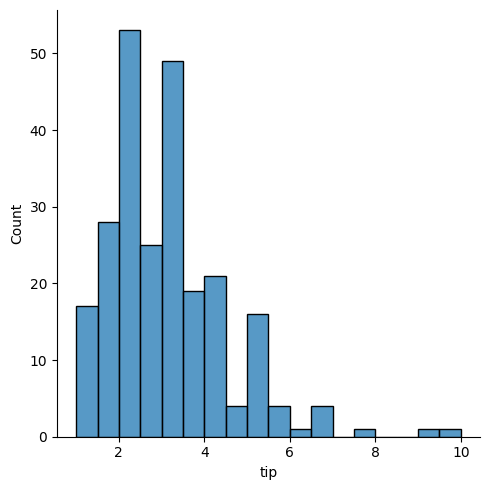

In [18]:
# Funkcja "Figure-level" - tworzymy całą figurę = mamy dostęp do siatki
# możemy tworzyć w obrębie siatki większą liczbę wykresów
sns.displot(data = df, x = 'tip') # domyślny kind = 'hist' ()
plt.savefig('wykres.png', dpi=300)
# inne typy 'kde' (krzywa gęstości, Kernel Density Estimation) - opisuje rozkład prawdopodobieństwa
# skumulowany rozkład empiryczny ('ecdf')

<Axes: xlabel='tip', ylabel='Count'>

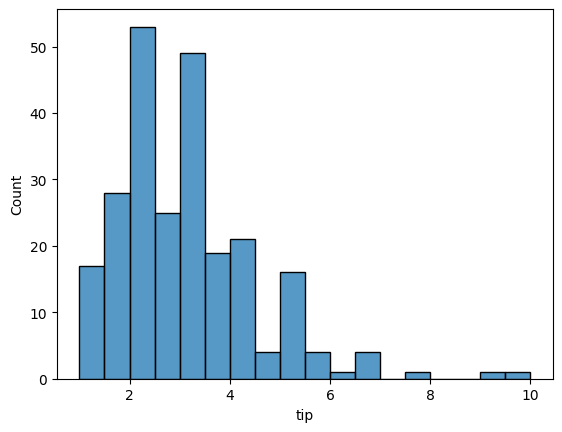

In [19]:
# Funkcje "Axes-level" - rysujemy jeden wykres w jednym polu wykresu
# Łatwiej łączyć z matplotlib
sns.histplot(data = df, x = 'tip')

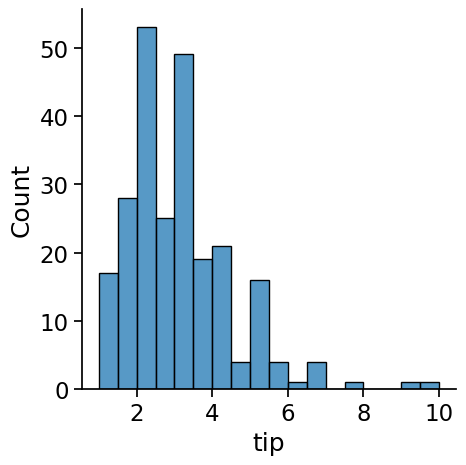

In [20]:
sns.set_context('notebook', font_scale=1.5)
# paper, notebook, talk, poster
sns.displot(data = df, x = 'tip')
plt.savefig('wykres.png', dpi=300)

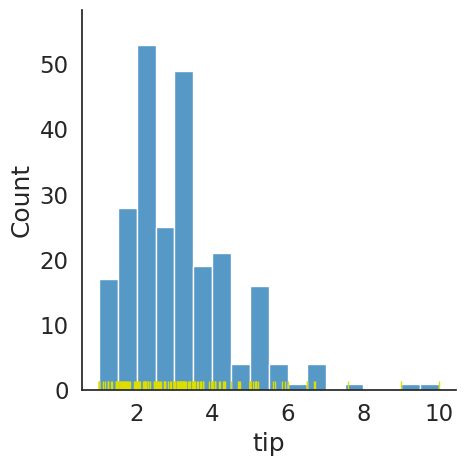

In [21]:
# sns.set_context('notebook', font_scale = 1.5)
sns.set_style('white')  # white, dark, whitegrid, darkgrid, ticks
sns.displot(data = df, x = 'tip') # rug = True
sns.rugplot(data = df, x = 'tip', color = '#DDDD00')
plt.savefig('wykres.png', dpi=300)

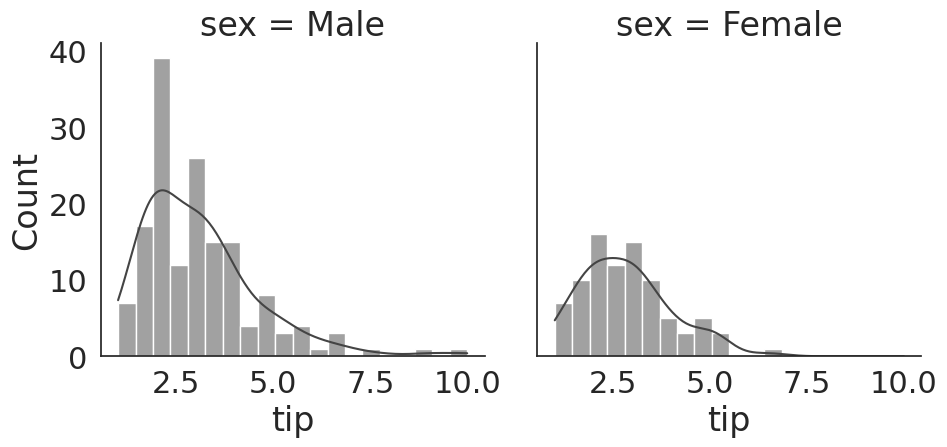

In [22]:
sns.set_context('notebook', font_scale = 2)
# kolejne argumenty
sns.displot(data = df, x = 'tip', bins = 20,
            kde = True, col = 'sex', color='#444444')
plt.savefig('wykres.png', dpi=300)

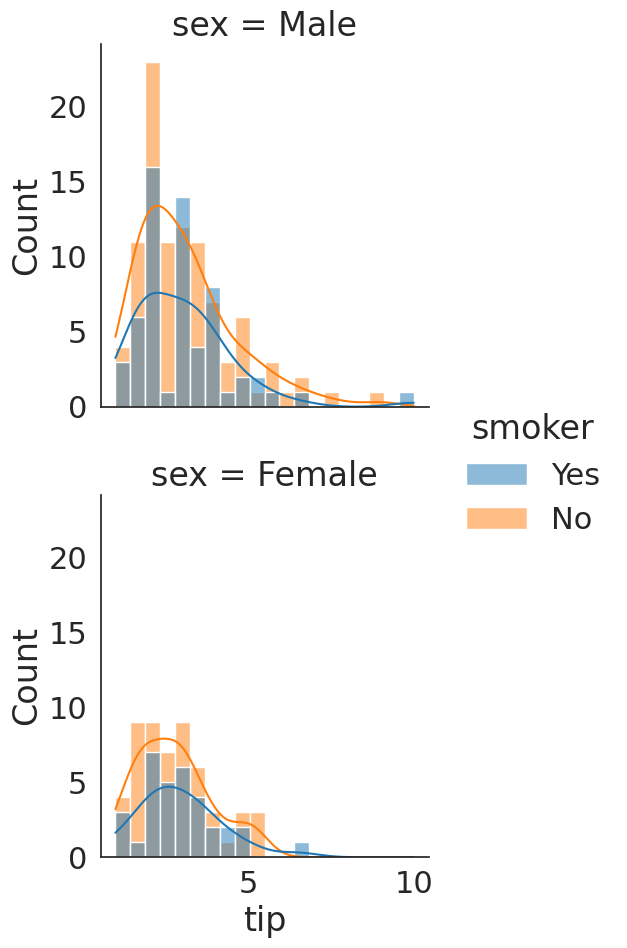

In [23]:
# hue - uwaga na nakładające się słupli (domyślnie multiple='layer')
sns.displot(data = df, x = 'tip', bins = 20,
            kde = True, row = 'sex', hue = 'smoker')
plt.savefig('wykres.png', dpi=300)

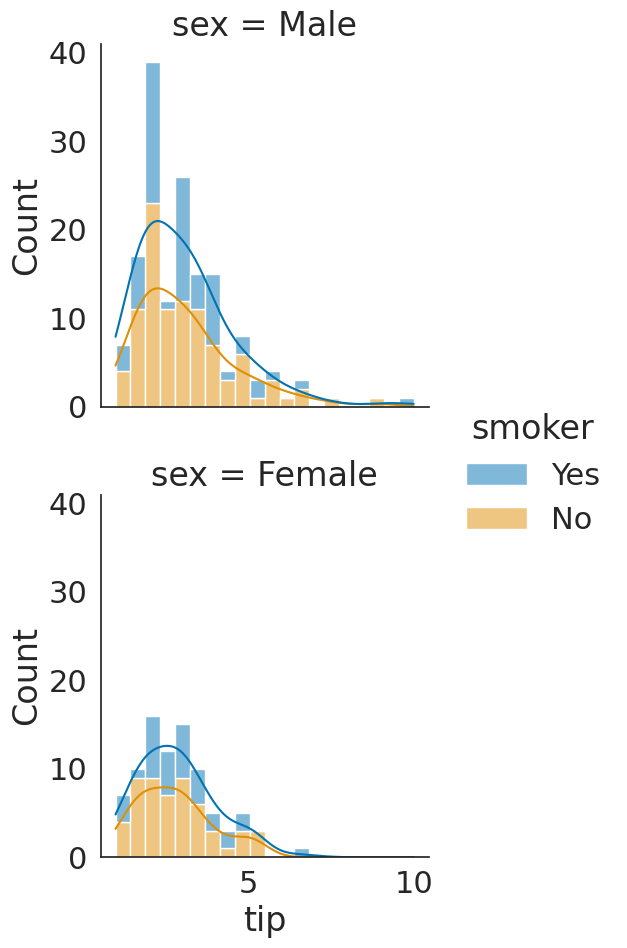

In [24]:
sns.displot(data = df, x = 'tip', bins = 20, kde = True,
            row = 'sex', hue = 'smoker',
            palette='colorblind', # Set2, muted, bright, pastel, dark
            multiple='stack') # stack, dodge, fill
plt.savefig('wykres.png', dpi=300)

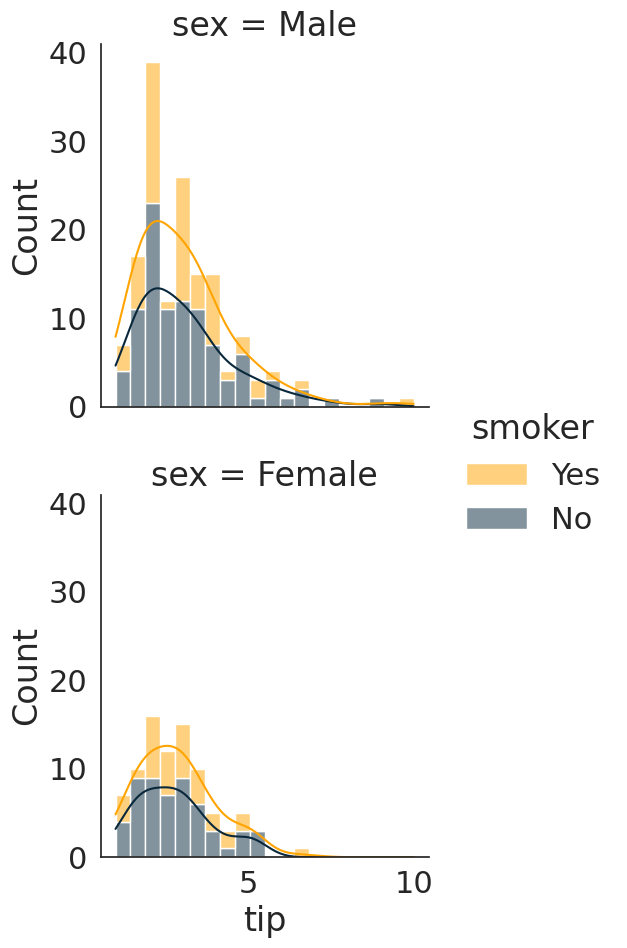

In [25]:
sns.displot(data = df, x = 'tip', bins = 20,
            kde = True, row = 'sex', hue = 'smoker',
            palette=['#FFA400','#09283C'],
            multiple='stack')
plt.savefig('wykres.png', dpi=300)

In [26]:
df1 = sns.load_dataset('taxis')
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

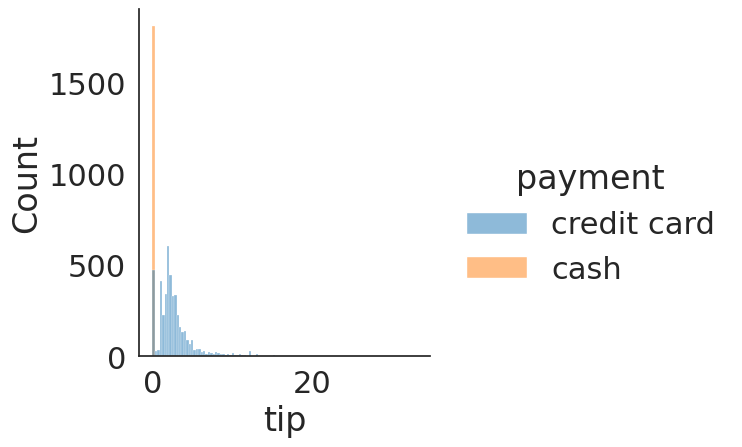

In [27]:
sns.displot(data = df1, x = 'tip', hue = 'payment') # zmienna typu object

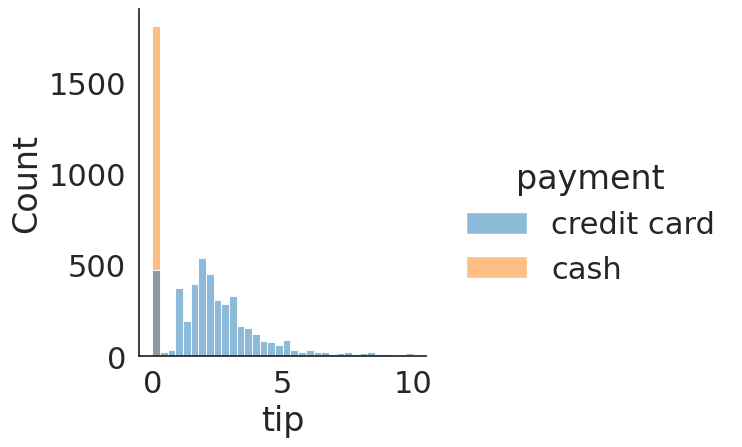

In [28]:
sns.displot(data = df1.query('tip<=10'), x = 'tip', hue = 'payment')

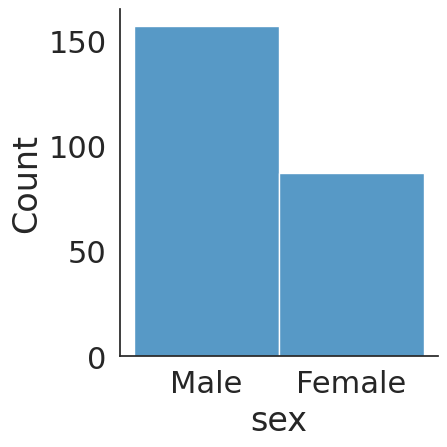

In [29]:
sns.displot(data = df, x = 'sex')
plt.savefig('wykres.png', dpi=300)

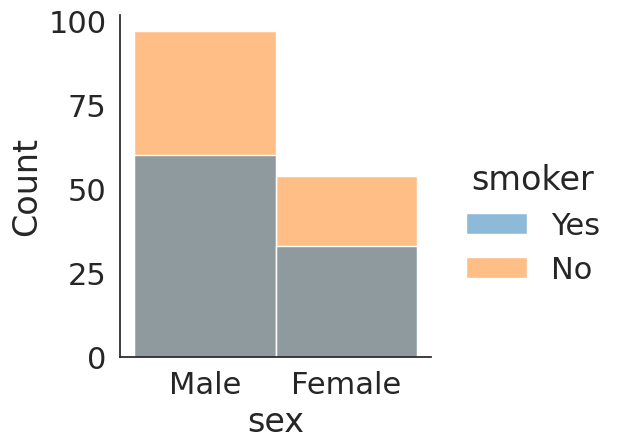

In [30]:
sns.displot(data = df, x = 'sex', hue = 'smoker')
plt.savefig('wykres.png', dpi=300)

### Funkcja catplot()

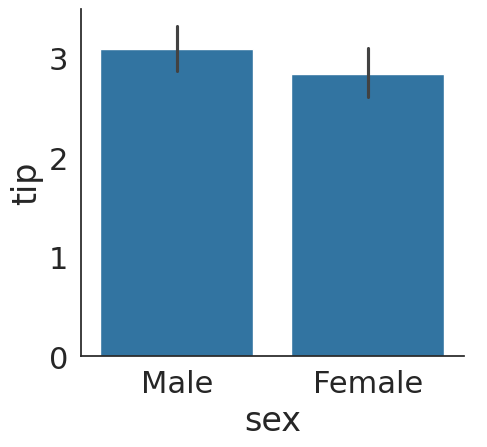

In [31]:
# Figure-level - kontrolujemy siatkę wykresów
# kind = "strip", "swarm", "box", "violin", "boxen", "point" (średnie + CI), "bar"
sns.catplot(data=df, x='sex', y='tip', kind='bar')
plt.savefig('wykres.png', dpi=300)

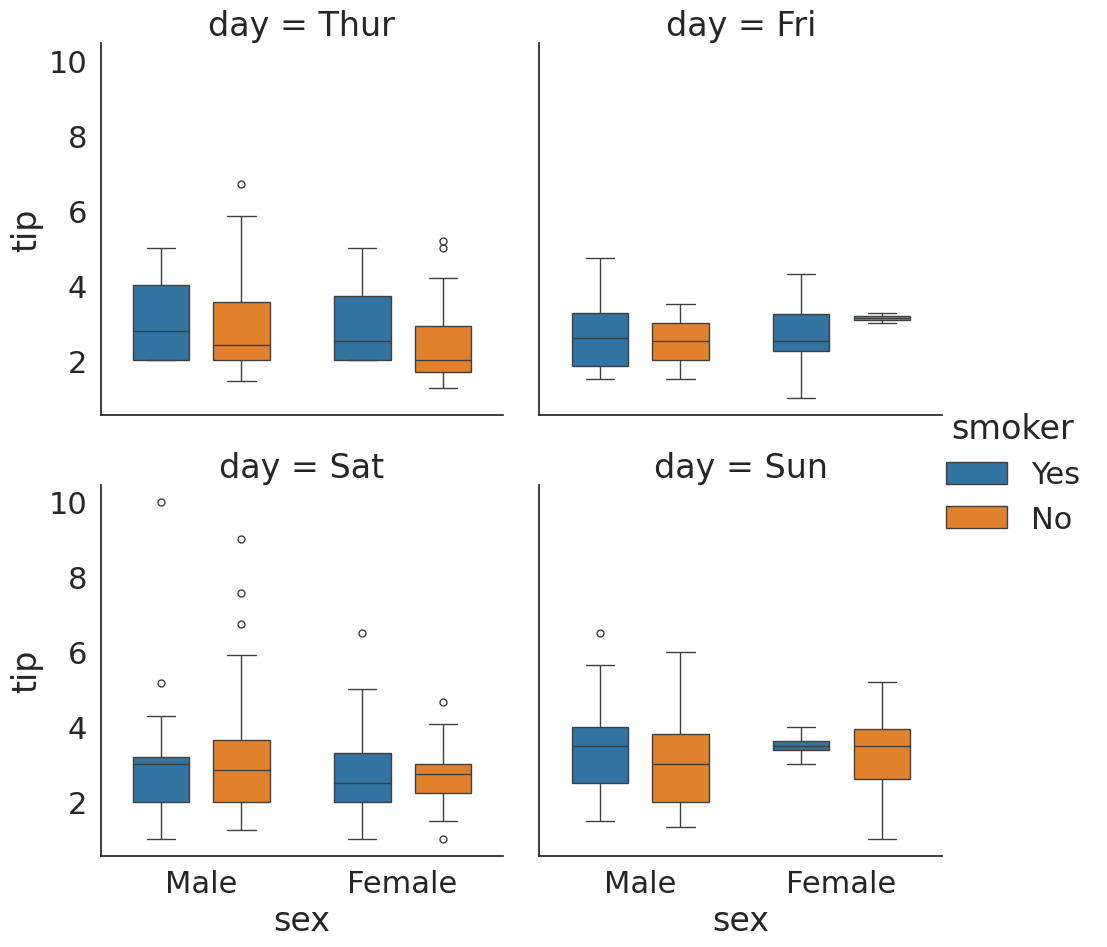

In [32]:
sns.catplot(data=df, x='sex', y='tip',
            hue='smoker', gap = 0.3, col='day',
            kind='box', col_wrap = 2)
plt.savefig('wykres.png', dpi=300)

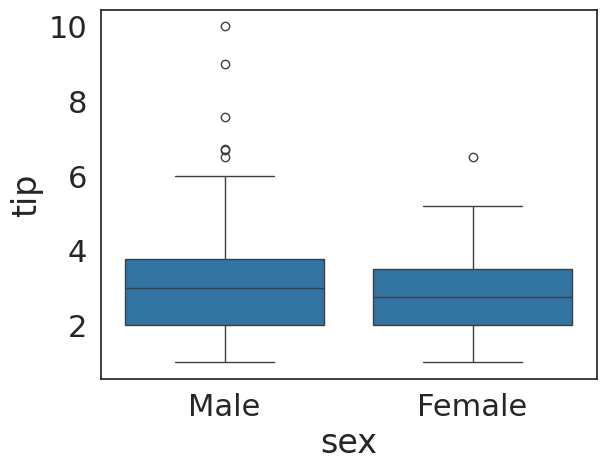

In [33]:
# axes-level - kontrolujemy jeden wykres
sns.boxplot(data = df, x = 'sex', y = 'tip')
plt.savefig('wykres.png', dpi=300)
# tu argument col/row nie zadziała - nie obsługuje siatki

## Część 2

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset('tips')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


### Funkcja relplot()

relplot() - Figure-level - kontrolujemy siatkę wykresów <br>
*   kind="scatter"; the default
*   kind="line"




#### kind="scatter"

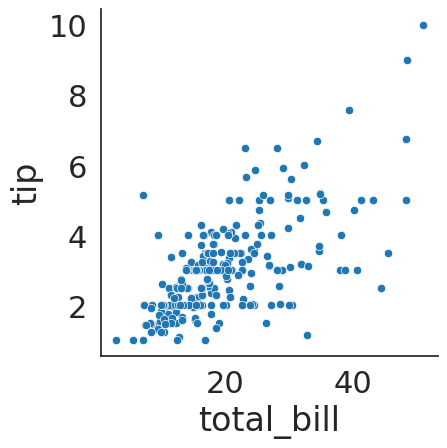

In [35]:
sns.set_context('notebook', font_scale=2)
sns.set_style('white')
sns.relplot(data = df, x = 'total_bill', y = 'tip')
plt.savefig('wykres.png', dpi=300)

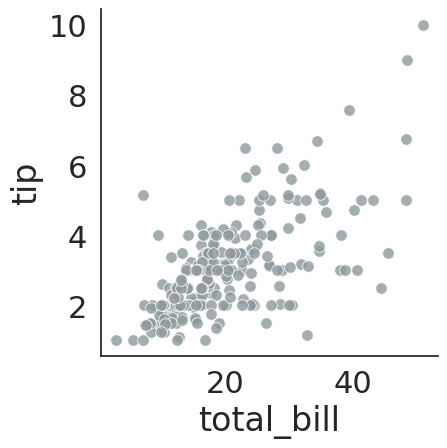

In [36]:
sns.relplot(data = df, x = 'total_bill',
            y = 'tip', s = 70, alpha = 0.8,
            color = '#8e9a9d')
plt.savefig('wykres.png', dpi=300)

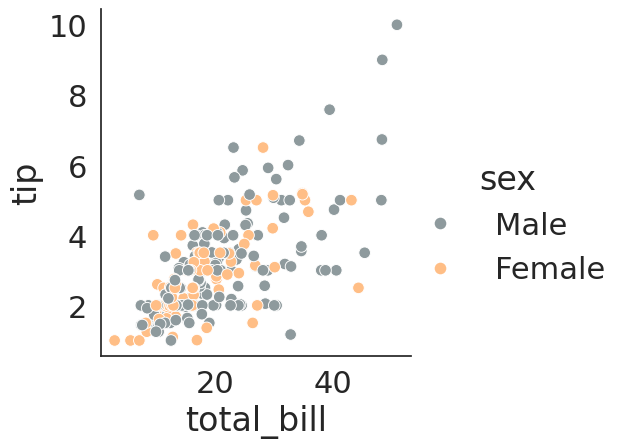

In [37]:
sns.relplot(data = df, x = 'total_bill',
            y = 'tip', s = 70,
            #palette="Set1",
            palette = ['#8e9a9d', '#ffbe86'],
            hue = 'sex')
plt.savefig('wykres.png', dpi=300)

In [38]:
df["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

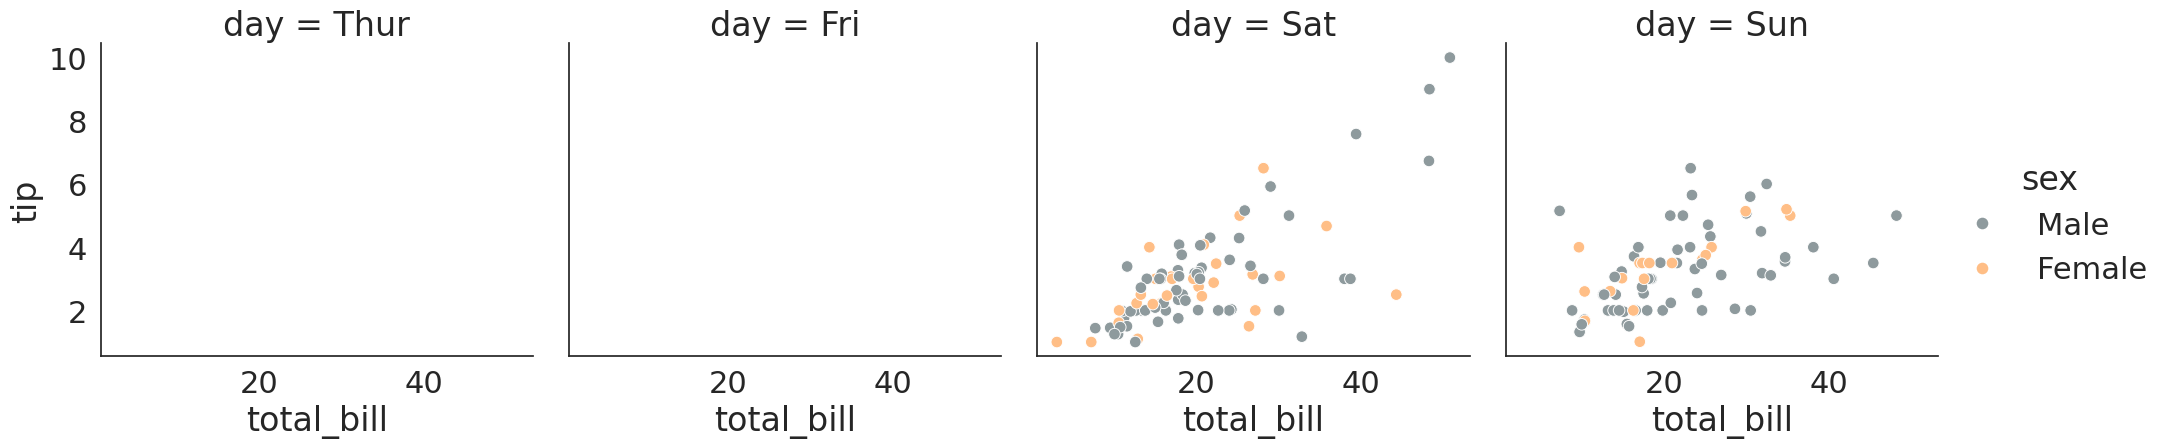

In [39]:
sns.relplot(data = df.query('day in ["Sat", "Sun"]'),
            x = 'total_bill', y = 'tip', s = 70,
            palette = ['#8e9a9d', '#ffbe86'],
            hue = 'sex', col = 'day')
plt.savefig('wykres.png', dpi=300)

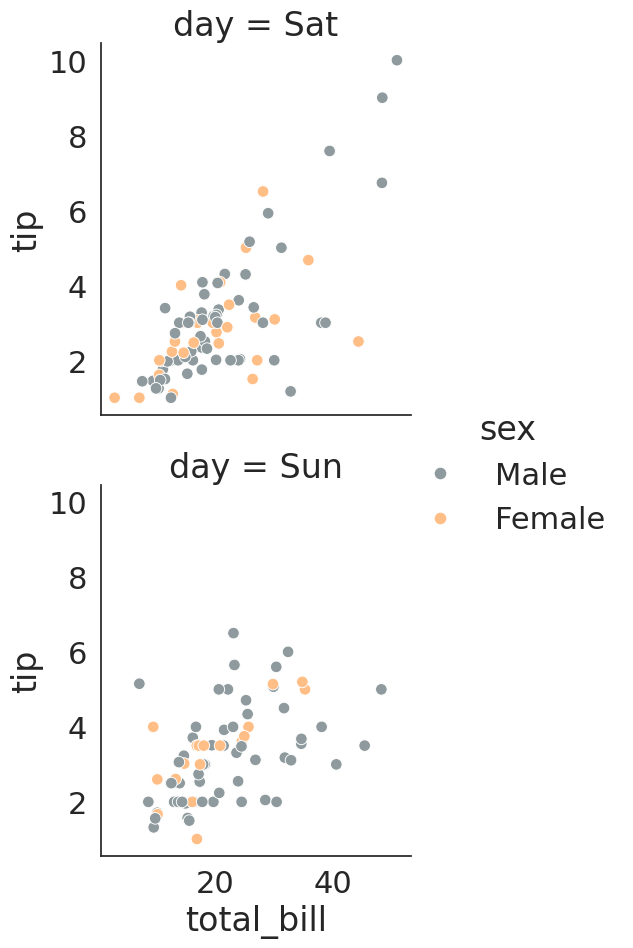

In [40]:
df2 = df.query('day in ["Sat", "Sun"]').copy()
df2["day"] = df2["day"].cat.remove_unused_categories()
sns.relplot(data = df2,
            x = 'total_bill', y = 'tip', s = 70,
            palette = ['#8e9a9d', '#ffbe86'],
            hue = 'sex', row = 'day')
plt.savefig('wykres.png', dpi=300)

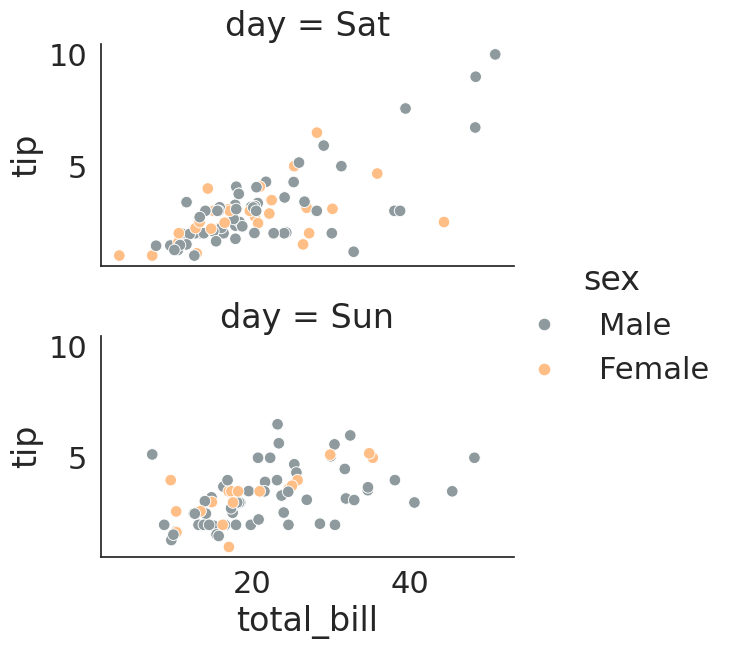

In [41]:
sns.relplot(data = df2,
            x = 'total_bill', y = 'tip', s = 70,
            palette = ['#8e9a9d', '#ffbe86'],
            hue = 'sex', row = 'day',
            height = 3.5, aspect = 1.7)
# aspect - szerokość = 1.7 * wysokość
# bbox_inches="tight"
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

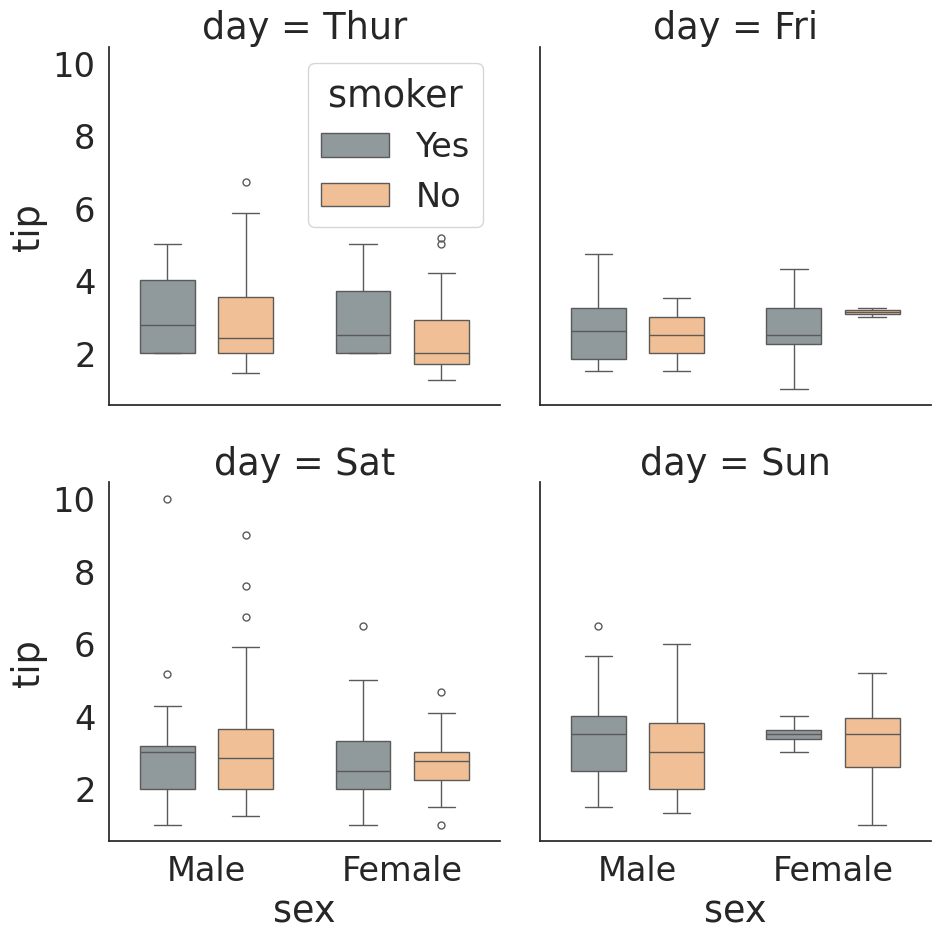

In [42]:
# wracamy jeszcze do boxplot
sns.set_context('notebook', font_scale=2.2)
sns.catplot(data=df, x='sex', y='tip',
            hue='smoker', gap = 0.3, col='day',
            kind='box', col_wrap = 2,
            palette = ['#8e9a9d', '#ffbe86'],
            legend_out = False)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

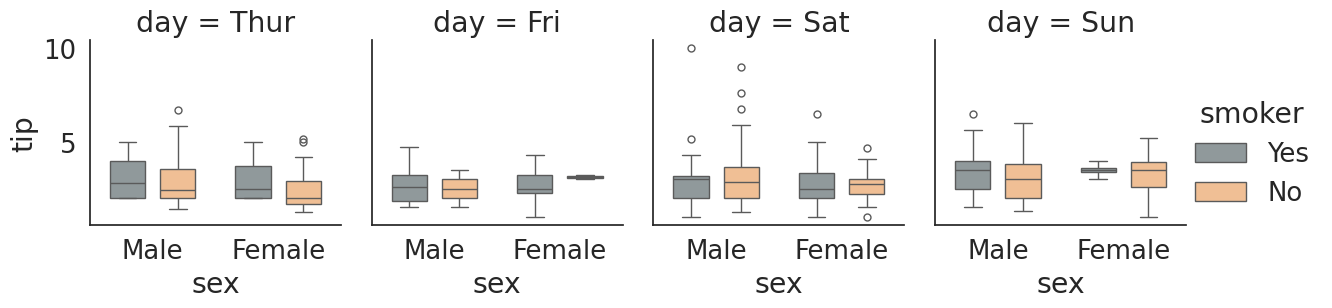

In [43]:
sns.set_context('notebook', font_scale=1.7)
sns.catplot(data=df, x='sex', y='tip',
            hue='smoker', gap = 0.3, col='day',
            kind='box',
            palette = ['#8e9a9d', '#ffbe86'],
            height = 3.5, aspect = 0.9)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

#### kind="line"
relplot()

In [44]:
import pandas as pd
df1 = sns.load_dataset("flights")
# df1 = df1.pivot("month", "year", "passengers")
df1.info()
df1.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [45]:
# %Y rok 4-cyfrowy (np. 2026), %b - skrót nazwy miesiąca
pd.to_datetime("2026-Jan", format="%Y-%b")

Timestamp('2026-01-01 00:00:00')

In [46]:
df1["date"] = pd.to_datetime(
    df1["year"].astype(str) + "-" + df1["month"].astype(str),
    format="%Y-%b"
)
df1.info()
df1['year'].max()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   date        144 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 4.0 KB


1960

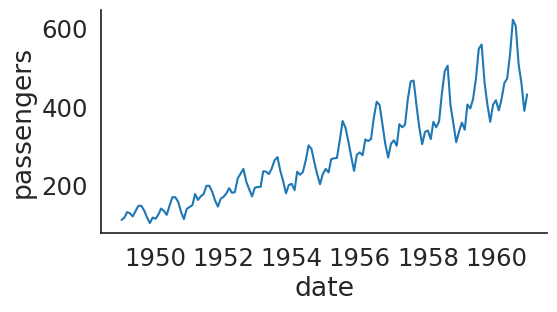

In [47]:
sns.set_context('notebook', font_scale=1.6)
sns.relplot(data=df1, x="date", y="passengers",
            kind="line", height = 3.5, aspect = 1.7)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

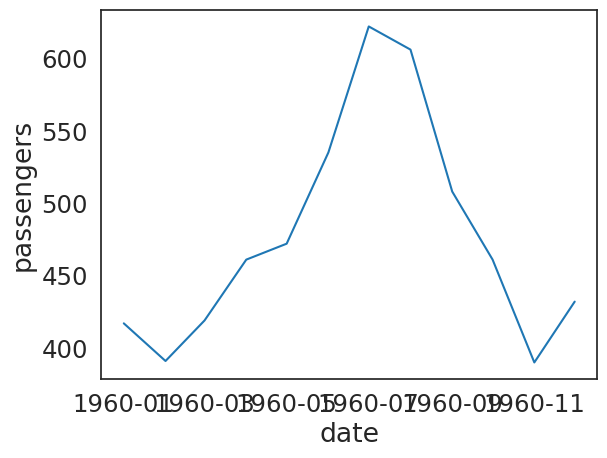

In [48]:
# odpowiednik # axes-level - kontrolujemy jeden wykres
sns.lineplot(data=df1.query('year == 1960'), x="date", y="passengers")
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

### Funkcja lmplot()
Wykresy regresji

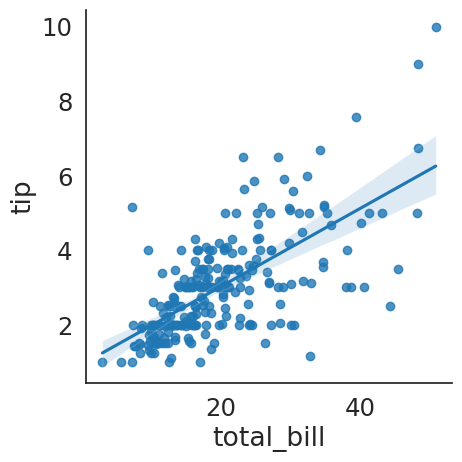

In [49]:
# Figure-level
sns.lmplot(data=df, x="total_bill", y="tip")
# domyślnie ci = 0.95 obliczane na podstawie bootstrap

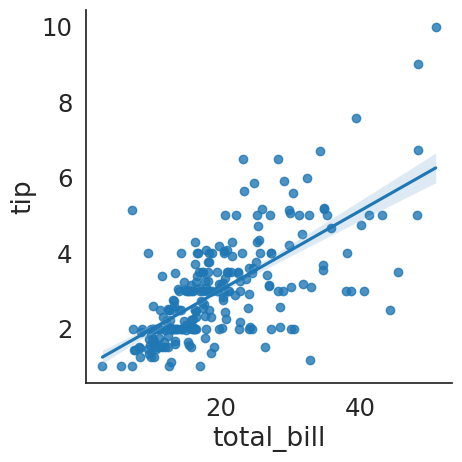

In [50]:
sns.lmplot(data=df, x="total_bill", y="tip", ci = 68)

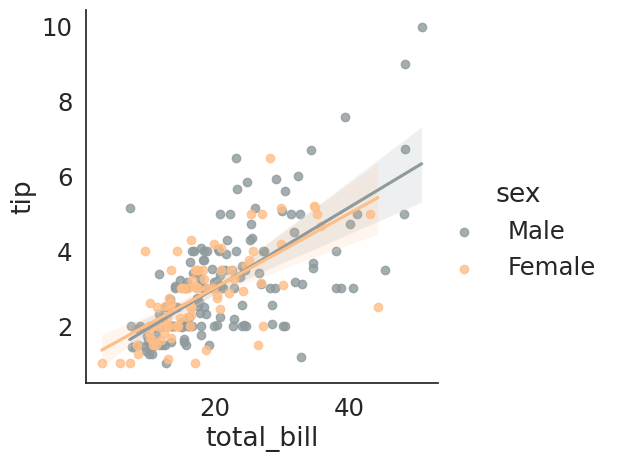

In [51]:
sns.lmplot(data=df, x="total_bill", y="tip",
           hue = 'sex', palette = ['#8e9a9d', '#ffbe86'])
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

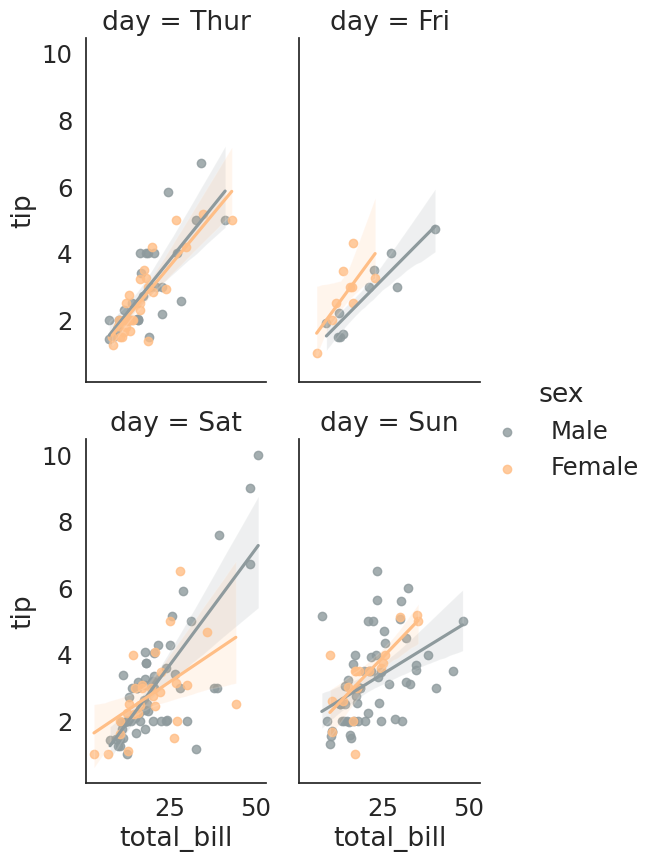

In [52]:
sns.lmplot(data=df, x="total_bill", y="tip",
           hue = 'sex', palette = ['#8e9a9d', '#ffbe86'],
           col = "day", col_wrap = 2,
           height = 4.5, aspect = 0.6)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

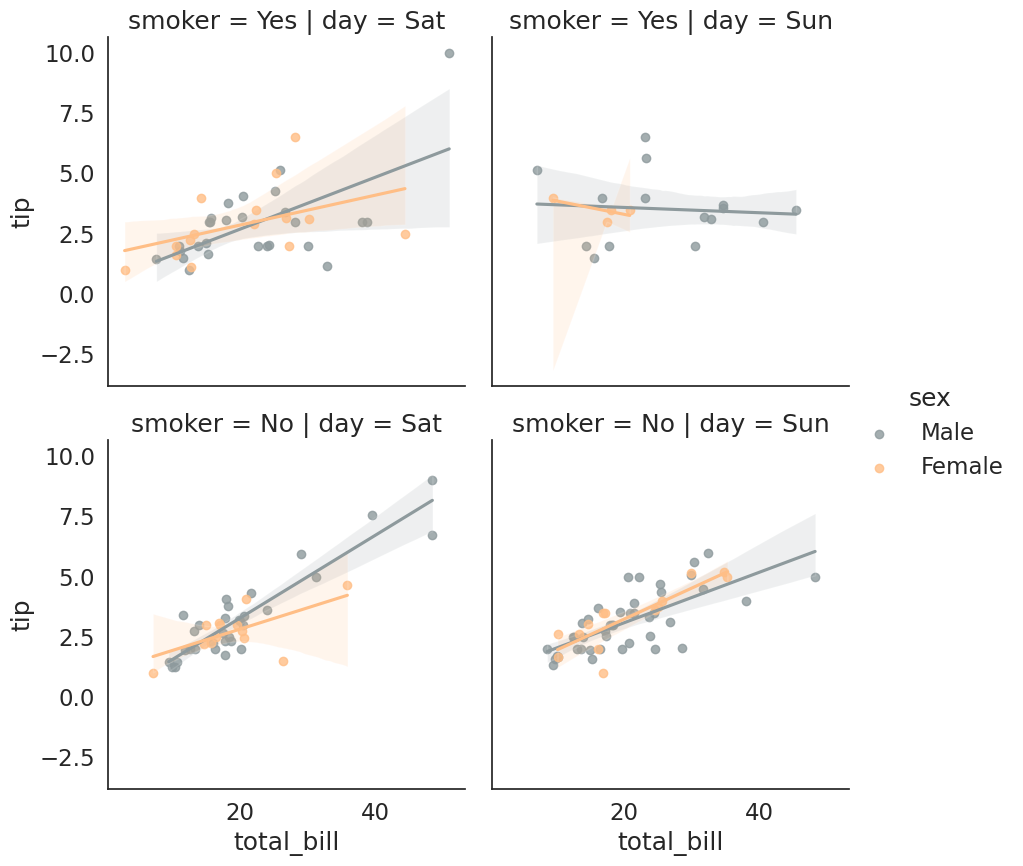

In [53]:
sns.set_context('notebook', font_scale=1.5)
sns.lmplot(data=df2, x="total_bill", y="tip",
           hue = 'sex', palette = ['#8e9a9d', '#ffbe86'],
           col = "day", row = "smoker",
           height = 4.5, aspect = 1)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

In [54]:
df2['total_bill'].max()
df2['tip'].max()

10.0

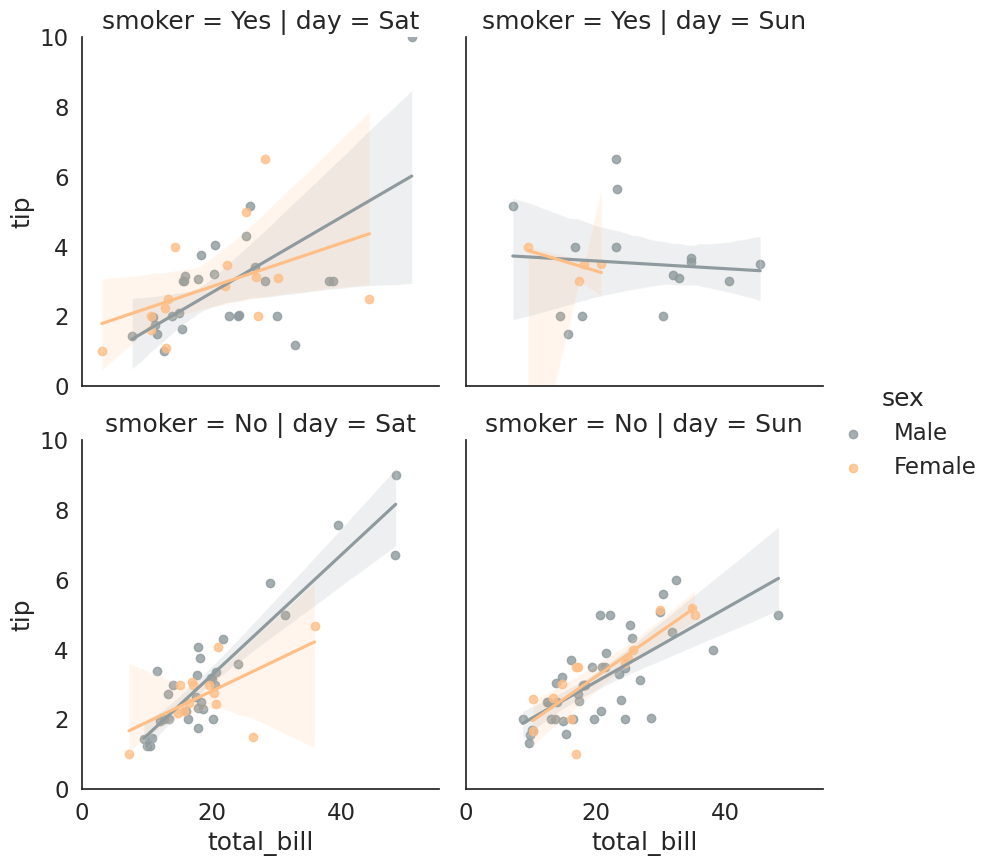

In [55]:
sns.set_context('notebook', font_scale=1.5)
wykres = sns.lmplot(data=df2, x="total_bill", y="tip",
           hue = 'sex', palette = ['#8e9a9d', '#ffbe86'],
           col = "day", row = "smoker",
           height = 4.5, aspect = 1)
wykres.set(xlim=(0, 55), ylim=(0, 10))
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

### Łączenie różnych wykresów
Funkcje "Axes-level" - kontrolujemy pojedyncze wykresy, które możemy połączyć

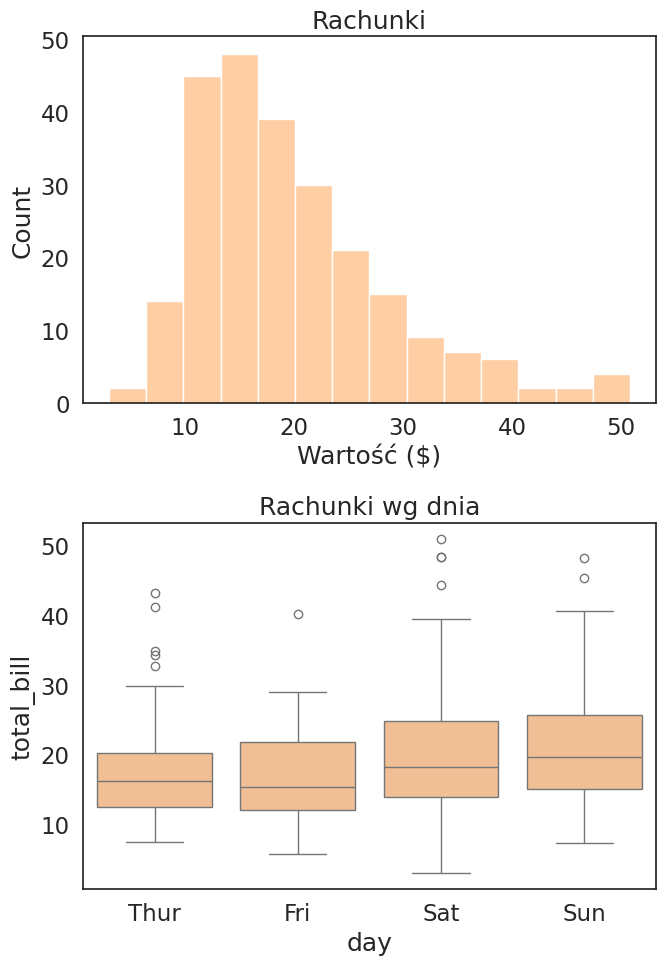

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(7, 10))
# wiersze, kolumny, szerokość, wysokość w calach
sns.histplot(data=df, x="total_bill",
             color = '#ffbe86',ax=axes[0])
axes[0].set_title("Rachunki")
axes[0].set_xlabel("Wartość ($)")

sns.boxplot(data=df, x="day", y="total_bill",
            color = '#ffbe86', ax=axes[1])
axes[1].set_title("Rachunki wg dnia")
plt.tight_layout()  # nie chcemy żeby wykresy nachodziły na siebie (kolejna metoda)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

In [57]:
df['total_bill'].mean()

np.float64(19.78594262295082)

/tmp/ipykernel_24896/931638777.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="total_bill",


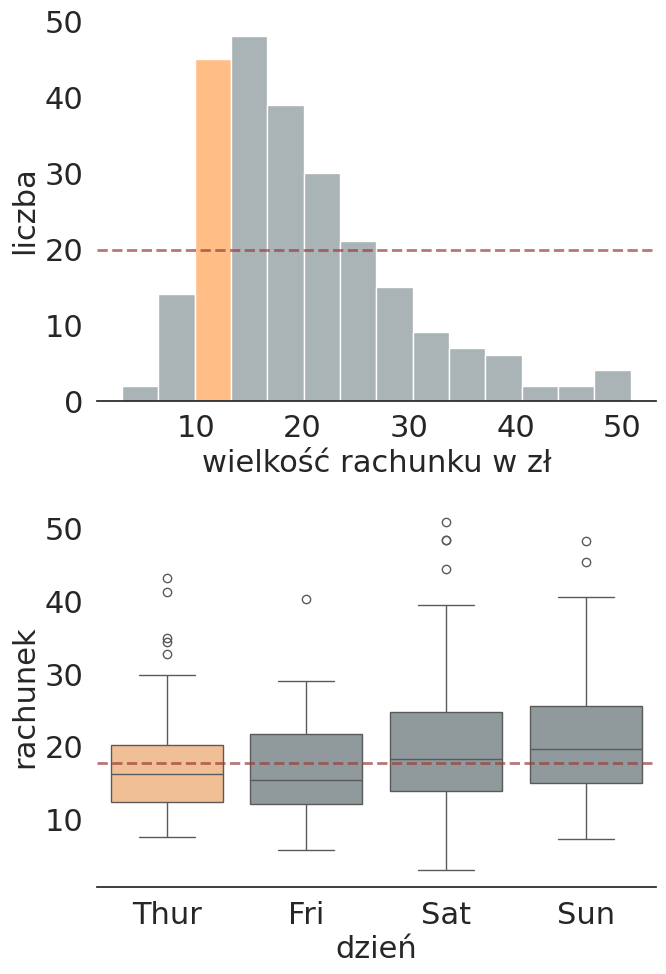

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(7, 10))


sns.histplot(data=df, x="total_bill",
             color = '#8e9a9d',ax=axes[0])
srednia = df['total_bill'].mean()
axes[0].axhline(y=srednia, color='#993d3d', linestyle='--',
                linewidth=2, alpha = .7)
patches = axes[0].patches # pobieramy słypki
patches[2].set_facecolor('#ffbe86') # określamy kolor trzeciego

palette = {
    "Thur": "#ffbe86",   # inny kolor
    "Fri": "#8e9a9d",
    "Sat": "#8e9a9d",
    "Sun": "#8e9a9d"
}

sns.boxplot(data=df, x="day", y="total_bill",
            color = '#8e9a9d', ax=axes[1],
            palette=palette)
mediana = df['total_bill'].median()
axes[1].axhline(y=mediana, color='#993d3d', linestyle='--',
                linewidth=2, alpha = .7)
sns.despine(left = True)   # można dodać np left = True
axes[0].tick_params(axis='both', labelsize=22)
axes[0].set_xlabel("wielkość rachunku w zł",fontsize=22)
axes[0].set_ylabel("liczba", fontsize=22)
axes[1].tick_params(axis='both', labelsize=22)
axes[1].set_xlabel("dzień",fontsize=22)
axes[1].set_ylabel("rachunek", fontsize=22)

plt.tight_layout()
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

## Część 3

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset('taxis')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [60]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [61]:
cash = df.query('payment=="cash"')
print(cash['tip'].mean())
card = df.query('payment=="credit card"')
print(card['tip'].mean())
df.groupby("payment")["tip"].describe()

0.0
2.781804675551671


,count,mean,std,min,25%,50%,75%,max
payment,,,,,,,,
cash,1812.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
credit card,4577.0,2.781805,2.488783,0.0,1.5,2.2,3.26,33.2


In [62]:
df = df.query('payment=="credit card"')

### Wykres ze statystykami

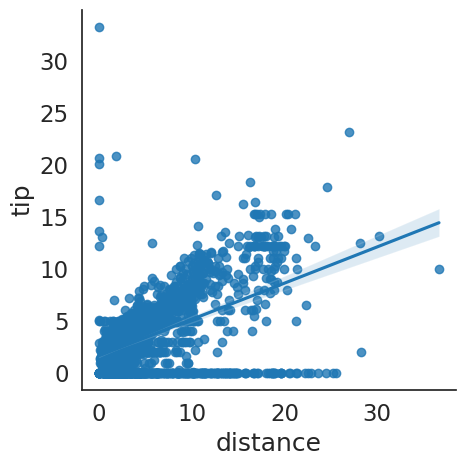

In [63]:
# Figure-level
sns.lmplot(data=df, x="distance", y="tip")
# domyślnie 95% confidence interval dla estymowanej linii regresji
# obszar estymowany techniką bootstrap
# w praktyce - 95% przewidywanych y (liczonych oddzielnie dla każdego x) tworzy granicę pasa


In [64]:
from scipy import stats # z pakietu scipy importuj moduł stats (szereg statystyk)
stats.describe(df['tip'])

DescribeResult(nobs=np.int64(4577), minmax=(np.float64(0.0), np.float64(33.2)), mean=np.float64(2.781804675551671), variance=np.float64(6.194039967958903), skewness=np.float64(2.7696086334196317), kurtosis=np.float64(13.358734072317901))

In [65]:
stats.pearsonr(df['distance'], df['tip'])
# H0​:ρ=0 (brak liniowej korelacji w populacji)

PearsonRResult(statistic=np.float64(0.5517558416016178), pvalue=np.float64(0.0))

In [66]:
statistic = stats.pearsonr(df['distance'], df['tip'])
print(type(statistic)) # uzyskujemy tu taki obiekt

<class 'scipy.stats._stats_py.PearsonRResult'>


In [67]:
statistic, pvalue = stats.pearsonr(df['distance'], df['tip'])
print(statistic, pvalue)

0.5517558416016178 0.0


In [68]:
stats.spearmanr(df['distance'], df['tip'])
# Calculate a Spearman correlation coefficient with associated p-value.

SignificanceResult(statistic=np.float64(0.45119696415132104), pvalue=np.float64(1.9111328531668027e-228))

In [69]:
stats.linregress(df['distance'], df['tip']) # statystyki regresji liniowej
# slope - współczynnik kierunkowy prostej
# intercept - wyraz wolny
# rvalue - r Pearsona
# pvalue - testu hipotezy H0:slope=0


LinregressResult(slope=np.float64(0.348311247544546), intercept=np.float64(1.659600932607938), rvalue=np.float64(0.5517558416016181), pvalue=np.float64(0.0), stderr=np.float64(0.0077838422075728365), intercept_stderr=np.float64(0.03962870084073959))

In [70]:
# rozpakowujemy krotkę
slope, intercept, r_value, p_value, std_err = stats.linregress(df["distance"], df["tip"])
print(f"y = {slope:.4f}x + {intercept:.4f}")

y = 0.3483x + 1.6596


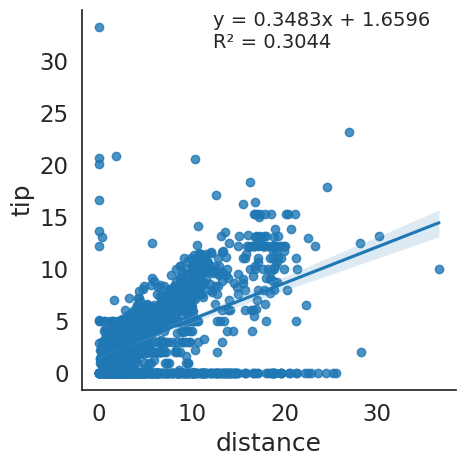

In [71]:
sns.set_context('notebook', font_scale=1.5)
ax = sns.lmplot(data=df, x="distance", y="tip")
label = f"y = {slope:.4f}x + {intercept:.4f}\nR² = {r_value**2:.4f}"
ax.ax.annotate(label, xy=(0.35, 0.9), xycoords="axes fraction", fontsize=14)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

# xycoords="axes fraction" - położenie legendy określane są w
# układzie względnym osi (od 0 do 1)

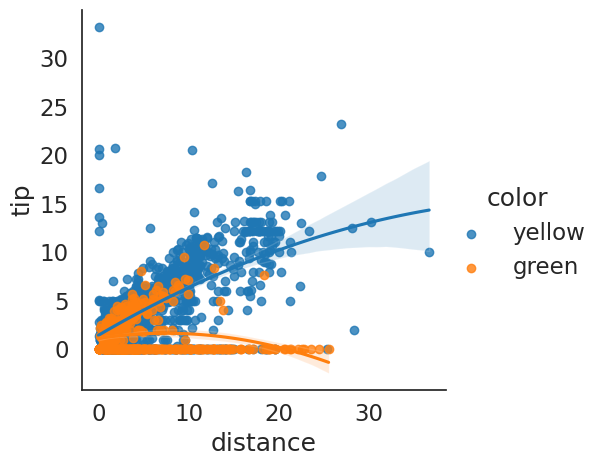

In [72]:
# regresja wielomianowa
sns.lmplot(data=df, x="distance", y="tip", order=2, hue="color")

In [73]:
import numpy as np

# Dopasowanie wielomianu stopnia 2 - równanie
coeffs = np.polyfit(df["distance"], df["tip"], 2)
print(coeffs)
a, b, c = coeffs # rozpakowujemy tablicę

print(f"y = {a:.4f}x² + {b:.4f}x + {c:.4f}")

[-0.00573035  0.44629435  1.49244449]
y = -0.0057x² + 0.4463x + 1.4924


In [74]:
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

X = df[["distance"]]
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = sm.OLS(df["tip"], X_poly).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     1020.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        16:10:33   Log-Likelihood:                -9823.1
No. Observations:                4577   AIC:                         1.965e+04
Df Residuals:                    4574   BIC:                         1.967e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4924      0.051     29.252      0.0

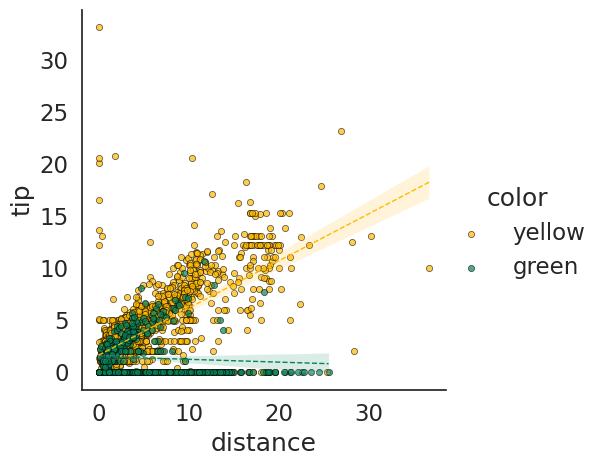

In [75]:
moja_paleta = {
    "yellow": "#FFB900",
    "green": "#088158"
}
sns.lmplot(data=df, x="distance", y="tip",
           hue="color",
           ci=99,
           scatter_kws={"alpha": 0.7,
                        "s" : 20,
                        "edgecolors" : "black",
                        "linewidths": 0.5
                        },
           line_kws={"lw": 1,
                     "ls": "--"},
           height=5, aspect=1,
           palette=moja_paleta)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

### Regresja logistyczna

     tip  duży_napiwek
0   2.15             0
2   2.36             0
3   6.15             0
4   1.10             0
5   2.16             0
6   2.00             0
8   1.00             0
9   1.00             0
11  2.16             0
12  1.00             0


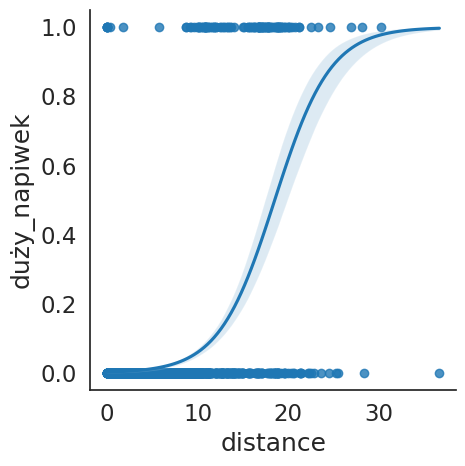

In [76]:
df["duży_napiwek"] = (df["tip"] > 10).astype(int) # bool -> int
print(df[['tip','duży_napiwek']].head(10)) # y wartości 0 i 1

sns.lmplot(data=df, x="distance", y="duży_napiwek",
           logistic=True)
# prawdopodobieństwo otrzymania dużego napiwku w zależności od dystansu
# np. (na oko) przy 25 km dystansu szansa na duży napiwek = 0.8

https://seaborn.pydata.org/generated/seaborn.lmplot.html#seaborn.lmplot

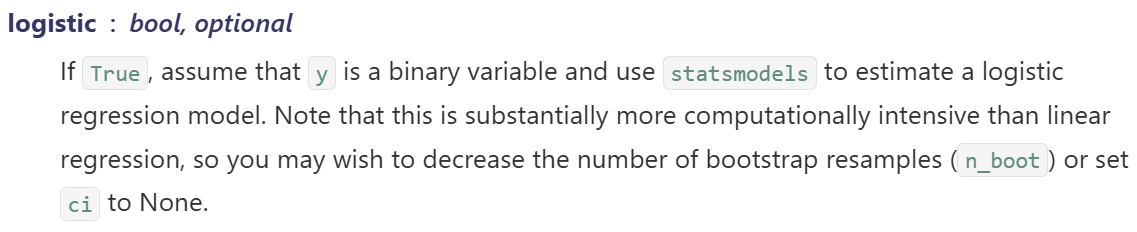

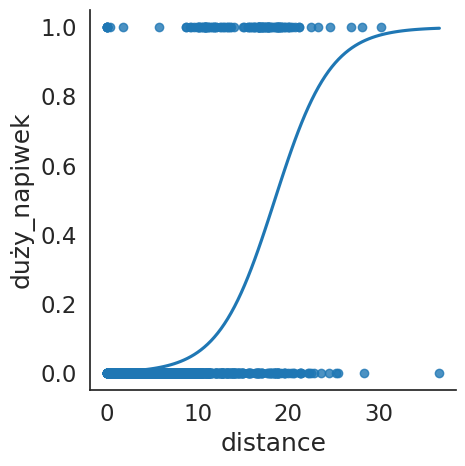

In [77]:
sns.lmplot(data=df, x="distance", y="duży_napiwek",
           logistic=True, ci = None)

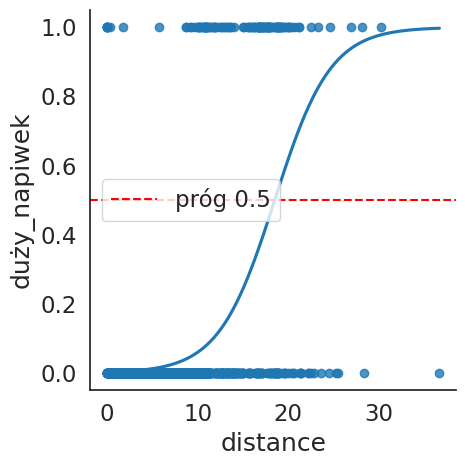

In [78]:
ax = sns.lmplot(data=df, x="distance", y="duży_napiwek",
                logistic=True, ci = None)

ax.ax.axhline(y=0.5, color="red", linestyle="--", lw=1.5, label="próg 0.5")
ax.ax.legend()
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

### Funkcja heatmap()

In [79]:
df = sns.load_dataset('flights')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [80]:
df.pivot(index="month", columns="year", values="passengers")

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


In [81]:
df = df.pivot(index="month", columns="year", values="passengers")

<Axes: xlabel='year', ylabel='month'>

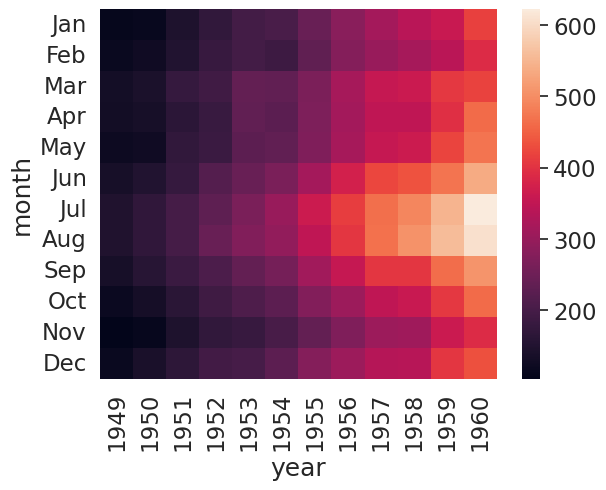

In [82]:
sns.heatmap(df)

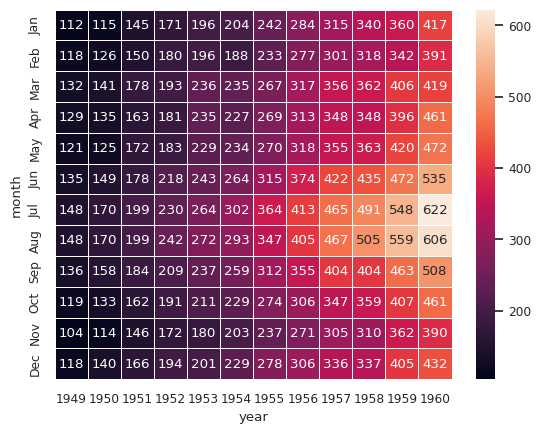

In [83]:
sns.set_context('notebook', font_scale=0.8)
sns.heatmap(df, annot=True,fmt=".0f", linewidth=.5)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

In [84]:
df = sns.load_dataset('taxis')

In [85]:
import pandas as pd
corr = df.corr(numeric_only=True) # domyślnie Pearson
print(corr)

            passengers  distance      fare       tip     tolls     total
passengers    1.000000  0.009411  0.007637  0.021099 -0.002903  0.015708
distance      0.009411  1.000000  0.920108  0.452589  0.635267  0.904676
fare          0.007637  0.920108  1.000000  0.488612  0.609307  0.974358
tip           0.021099  0.452589  0.488612  1.000000  0.413619  0.646186
tolls        -0.002903  0.635267  0.609307  0.413619  1.000000  0.683142
total         0.015708  0.904676  0.974358  0.646186  0.683142  1.000000


<Axes: >

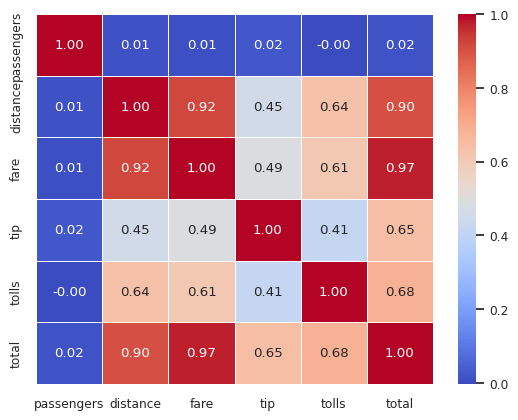

In [86]:
sns.heatmap(
    corr,
    annot=True,      # pokazuje wartości
    cmap="coolwarm", # kolory
    fmt=".2f",       # 2 miejsca po przecinku
    linewidths=0.5
)

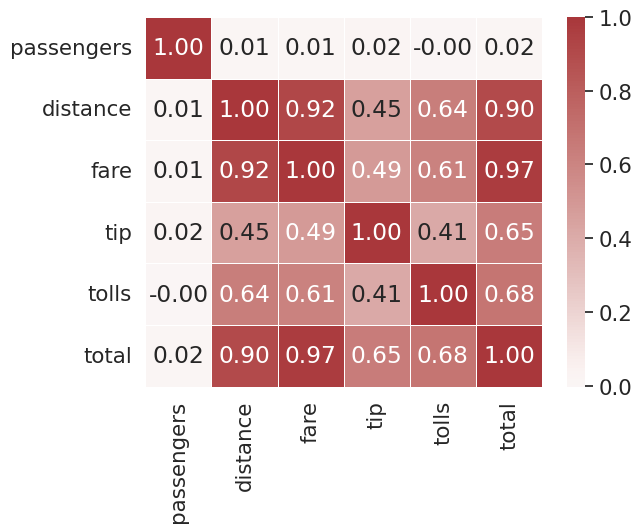

In [87]:
sns.set_context('notebook', font_scale=1.4)
sns.heatmap(
    corr,
    annot=True,      # pokazuje wartości
    cmap="vlag",     # kolory, inny - "RdBu_r"
    center = 0,      # centruj kolory do wartości 0 (a nie do środka zakresu korelacji)
    fmt=".2f",       # 2 miejsca po przecinku
    linewidths=0.5
)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

In [88]:
mask = np.triu(np.ones_like(corr, dtype=bool))
mask

array([[ True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True],
       [False, False, False, False,  True,  True],
       [False, False, False, False, False,  True]])

<Axes: >

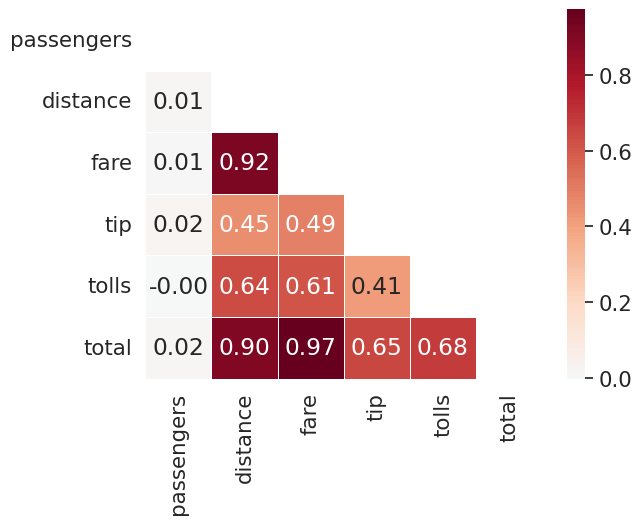

In [89]:
sns.heatmap(
    corr,
    mask = mask,    # tylko dolny trójkąt
    annot=True,
    cmap="RdBu_r",
    center = 0,
    fmt=".2f",
    linewidths=0.5
)

## Część 4. Przykład

In [90]:
import pandas as pd
import numpy as np
df = pd.read_excel('https://github.com/zarkadiuszem/student/raw/main/mieszkania.xlsx')
df.head(5)

,cena_wynajmu,liczba_metrów,dzielnica,liczba_osób,ocena_standardu,internet,minimalny_okres_wynajmu,kaucja,wymagane_poręczenie,rodzaj_ogrzewania,data_wynajmu,dostęp_miejsce_parking,uwagi
0,807,48,Zachód,3,Średni,Tak,1,True,1,centralne,2026-04-30,Nie,Brak
1,1659,73,Prawobrzeże,6,Wysoki,Tak,3,True,0,prąd,2026-04-20,Nie,Brak
2,1350,69,Północ,5,Średni,Tak,10,True,0,węgiel,2026-03-26,Nie,Brak
3,1784,65,Północ,4,Średni,Tak,9,True,0,centralne,2026-02-17,Nie,Brak
4,991,57,Północ,2,Niski,Tak,7,True,0,gazowe,2026-04-04,Nie,"Dobre ocieplenie, niskie koszty ogrzewania"


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   cena_wynajmu             356 non-null    int64 
 1   liczba_metrów            356 non-null    int64 
 2   dzielnica                356 non-null    object
 3   liczba_osób              356 non-null    object
 4   ocena_standardu          356 non-null    object
 5   internet                 356 non-null    object
 6   minimalny_okres_wynajmu  356 non-null    object
 7   kaucja                   356 non-null    bool  
 8   wymagane_poręczenie      356 non-null    int64 
 9   rodzaj_ogrzewania        356 non-null    object
 10  data_wynajmu             356 non-null    object
 11  dostęp_miejsce_parking   356 non-null    object
 12  uwagi                    356 non-null    object
dtypes: bool(1), int64(3), object(9)
memory usage: 33.9+ KB


In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

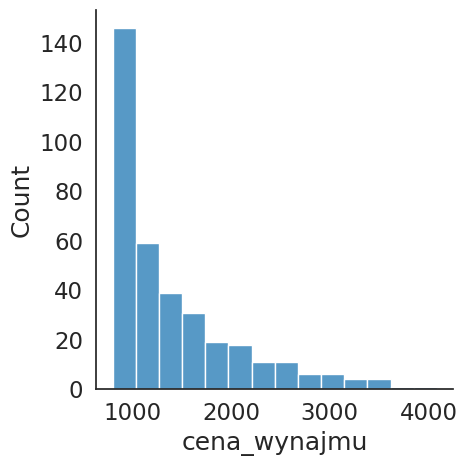

In [93]:

sns.set_context('notebook', font_scale=1.5)
sns.set_style('white')  # white, dark, whitegrid, darkgrid, ticks
# paper, notebook, talk, poster
sns.displot(data = df, x = 'cena_wynajmu')
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

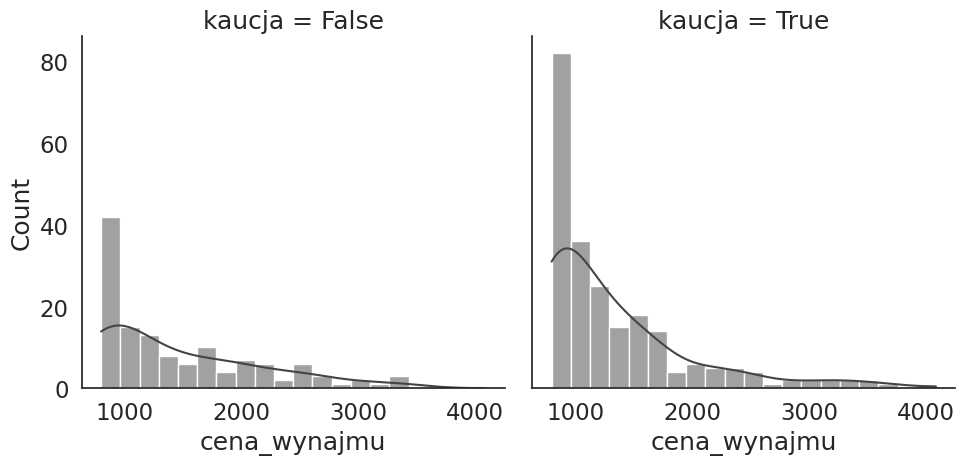

In [94]:
sns.displot(data = df, x = 'cena_wynajmu', bins = 20,
            kde = True, col = 'kaucja', color='#444444')
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")

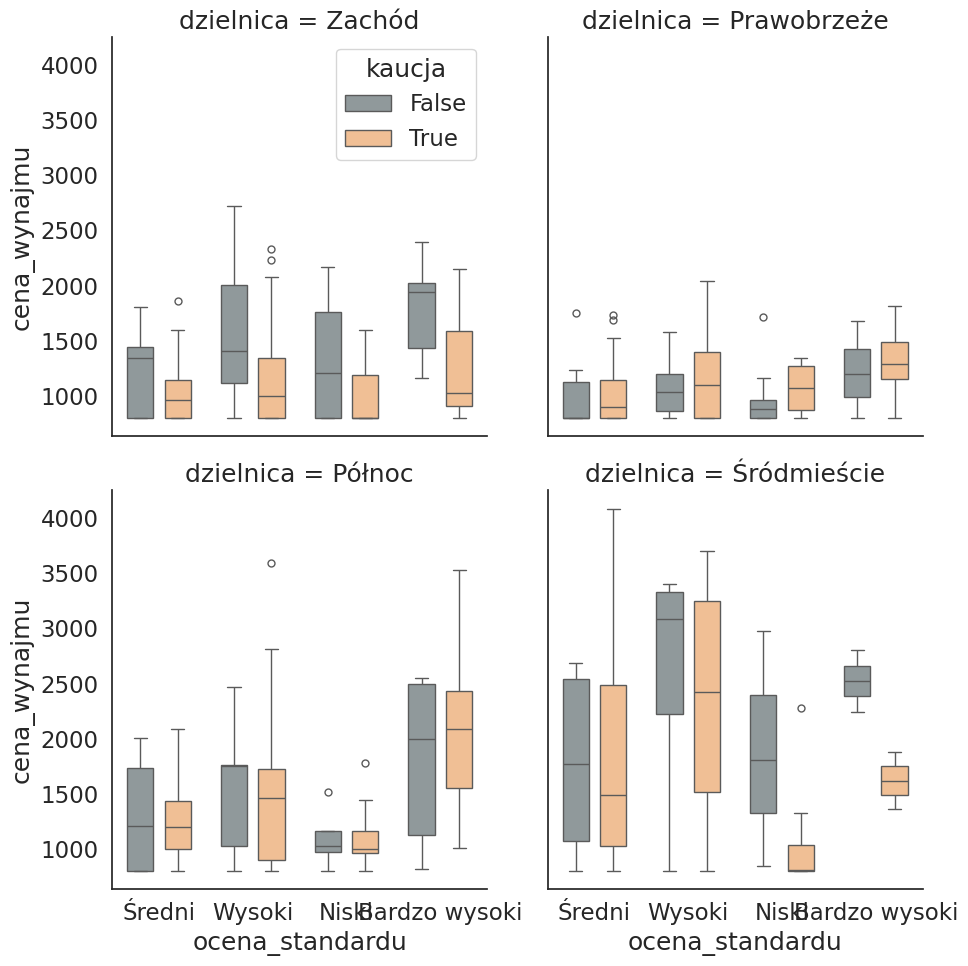

In [95]:
sns.catplot(data=df, x='ocena_standardu', y='cena_wynajmu',
            hue='kaucja', gap = 0.3, col='dzielnica',
            kind='box', col_wrap = 2,
            palette = ['#8e9a9d', '#ffbe86'],
            legend_out = False)
plt.savefig('wykres.png', dpi=300, bbox_inches="tight")